# Анализ поиска в Яндекс Картинках

**Дата:** 04.03.2026  
**Автор:** Свиридова Алена

**Цель исследования:** Проверить гипотезу о различии интересов пользователей мобильных и компьютерных версиях сервиса.  

**Инструменты:** Python (pandas, pandasql (SQL), matplotlib/seaborn), DataLens

**Используемые файлы и материалы:**  
data.tsv - семпл запросов к Яндекс Картинкам за несколько недель  (1114365 строк, 3 столбца)  
    Query - Запрос  
    Date - Дата  
    Device - Тип устройства  
[Дашборд в DataLens](https://datalens.yandex/jiqhmjsffdja3) - интерактивный дашборд по семплу data.tsv (описание Дашборда см.Пункт 5)

### Содержимое проекта
   1. [Знакомство с данными](#1-bullet)
   2. [Очистка и предобработка данных](#2-bullet)
   3. [Анализ по вопросам задания](#3-bullet)
   4. [Анализ недельной активности (SQL)](#4-bullet)
   5. [Дашборд в DataLens](#5-bullet)
   6. [Итоговые выводы и рекомендации](#6-bullet)

<a class="anchor" id="1-bullet"></a>
## Знакомство с данными

In [1]:
pip install pandasql

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.



In [2]:
# Библиотеки
import pandas as pd
import seaborn as sns
import numpy as np
import math
import re
import matplotlib.pyplot as plt
from IPython.display import HTML
# 5 вопрос кластеризации:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
# SQL
from pandasql import sqldf

In [3]:
df = pd.read_csv('data.tsv', sep='\t', header=None, names=['Query', 'Date', 'Device'])

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1114365 entries, 0 to 1114364
Data columns (total 3 columns):
 #   Column  Non-Null Count    Dtype 
---  ------  --------------    ----- 
 0   Query   1114365 non-null  object
 1   Date    1114365 non-null  int64 
 2   Device  1114365 non-null  object
dtypes: int64(1), object(2)
memory usage: 25.5+ MB


In [5]:
df.head()

,Query,Date,Device
0,малевич картины,1631806465,desktop
1,психология,1631781583,touch
2,с днём рождения лена,1631771563,touch
3,зверополис фильмы,1631787599,touch
4,алабай собака фото,1631786645,touch


На первый взгляд пропусков в данных нет.  
Даты представлены в Unix-timestamp.  
Данным в столбце Date требуется преобразование в тип datetime.

### Проверим содержание столбцов

In [6]:
print("Уникальные значения устройств (Device):",df['Device'].unique())


Уникальные значения устройств (Device): ['desktop' 'touch']


In [7]:
print("Количество уникальных запросов (Query):",df['Query'].nunique())


Количество уникальных запросов (Query): 31955


In [8]:
print(sorted(df['Query'].unique().tolist()))

['+18', '002', '02 аниме', '02 здоровье', '02 история', '02 кино', '02 кулинария', '02 милый во франсе', '02 мода', '02 новости', '02 образование', '02 путешествия', '02 спорт', '02 технологии', '02 фильмы', '1 день осени', '1 закон ньютона', '1 класс', '1 сентября', '1 сентября 2021', '1 сентября анимация', '1 сентября день знаний', '1 сентября день знаний картинки', '1 сентября картинка', '1 сентября картинки', '1 сентября картинки анимация', '1 сентября картинки для оформления', '1 сентября картинки поздравления', '1 сентября картинки поздравления для детей', '1 сентября картинки поздравления для учителей', '1 сентября картинки прикольные', '1 сентября картинки прикольные для родителей', '1 сентября картинки смешные', '1 сентября открытка', '1 сентября открытки', '1 сентября поздравление', '1 сентября поздравления', '1 сентября праздник', '1 сентября приколы', '1 сентября приколы для родителей', '1 сентября прикольные картинки', '1 сентября снова в польшу', '1 сентября учителю', '1 

Значения в столбце Device корректны: 'desktop' - компьютер, 'touch' -  мобильное устройство  
В столбце Query есть схожие запросы, например, "+18" "18+" "18 +" или 'Нептун', 'Нептун (планета)'.  
Посмотрим внимательнее.

In [9]:
total_unique = df['Query'].nunique()
print(f"\nВсего уникальных запросов в датасете: {total_unique}\n")

print("Примеры похожих запросов")

# Примеры групп похожих запросов. Перечисление ключевых слов для поиска и объединения в группы
patterns_to_check = {
    '1 сентября': r'1\s?сентября|первое\sсентября',
    'айфон 13': r'айфон\s13|iphone\s13|13\sайфон',
    '18+': r'18\+|\+18|18\s\+'
}

# Для каждой группы выведем первые 10 вариантов запросов, отсортирем по убыванию количества запросов
for pattern_name, pattern in patterns_to_check.items():
    matches = df[df['Query'].str.contains(pattern, case=False, na=False, regex=True)]
    
    if len(matches) > 0:
        counts = matches['Query'].value_counts()
        total = counts.sum()
        print(f"\n{pattern_name} - найдено {len(counts)} вариантов (всего {total} запросов):")
        
        for variant, count in counts.head(10).items():
            print(f"   - {variant} ({count} раз)")


Всего уникальных запросов в датасете: 31955

Примеры похожих запросов

1 сентября - найдено 169 вариантов (всего 13345 запросов):
   - с 1 сентября (1877 раз)
   - 1 сентября (1274 раз)
   - 1 сентября картинки (876 раз)
   - поздравление с 1 сентября (477 раз)
   - с 1 сентября картинки (426 раз)
   - открытки с 1 сентября (393 раз)
   - с 1 сентября поздравления (390 раз)
   - картинки с 1 сентября (255 раз)
   - поздравления с 1 сентября (243 раз)
   - открытка с 1 сентября (231 раз)

айфон 13 - найдено 33 вариантов (всего 5277 запросов):
   - айфон 13 (2129 раз)
   - iphone 13 (1067 раз)
   - 13 айфон (327 раз)
   - айфон 13 фото (283 раз)
   - айфон 13 цена (137 раз)
   - айфон 13 дата выхода (131 раз)
   - Айфон 13 (110 раз)
   - iphone 13 pro max (104 раз)
   - iphone 13 pro (83 раз)
   - айфон 13 про (72 раз)

18+ - найдено 38 вариантов (всего 1655 запросов):
   - 18+ (968 раз)
   - аниме 18+ (68 раз)
   - 18 + (58 раз)
   - бравл старс 18+ (49 раз)
   - +18 (45 раз)
   - цуна

Задача нормализации и объединения схожих поисковых запросов не была обозначена.  
В связи с этим, без согласования со старшим аналитиком, нельзя принимать решение об объединении семантически близких вариантов.  

Объединение запросов может существенно повлиять на:  
   - точность аналитики
   - корректность интерпретации результатов
   - расчет бизнес-метрик

Но для поиска контрасных тематик запросов (задании 5) проведем кластеризацию. 

In [10]:
# Сколько запросов содержат цифры
with_digits = df['Query'].str.contains(r'\d', na=False).sum()
print(f"\nЗапросов с цифрами: {with_digits} ({with_digits/len(df)*100:.1f}%)")

# Сколько запросов содерит английские буквы
with_english = df['Query'].str.contains(r'[a-zA-Z]', na=False).sum()
print(f"Запросов с английскими буквами: {with_english} ({with_english/len(df)*100:.1f}%)")


Запросов с цифрами: 95540 (8.6%)
Запросов с английскими буквами: 63714 (5.7%)


Запросы с цифрами и с английскими буквами по отдельности составляют менее 10% от датасета

In [11]:
print(f"Запросов с desktop: {df[df['Device']=='desktop']['Query'].count()} ({df[df['Device']=='desktop']['Query'].count()/len(df)*100:.1f}%)")
print(f"Запросов с touch: {df[df['Device']=='touch']['Query'].count()} ({df[df['Device']=='touch']['Query'].count()/len(df)*100:.1f}%)")

Запросов с desktop: 388264 (34.8%)
Запросов с touch: 726101 (65.2%)


### Вывод:  
   
Всего в датасете 1114365 строк, 3 столбца (Query, Date, Device), Размер в памяти: 25.5 MB    
Пропусков в данных нет.  
Уникальных запросов в датасете: 31955  
Уникальных типов устройств: 2 (desktop, touch)

Доли запросов с цифрами и с английскими буквами незначительны:  
- Доля запросов с английскими буквами 5.7%  
- Доля запросов с цифрами 8.6%
- Присутствуют запросы с иероглифами и смайликами

Доля запросов с мобильных устройств в 2-2.5 раза больше чем с компьютера.

Сделать: 
1) Преобразовать столбец Date в тип datetime
2) Столбцу Query провести безопасную нормализацию: приведение к нижнему регистру, удаление пробелов по краям, заменить "ё" на "е"

<a class="anchor" id="2-bullet"></a>
## Очистка и предварительная обработка данных

### Преобразование дат из Unix-timestamp в datetime

In [12]:
df['Date'] = pd.to_datetime(df['Date'], unit='s')
df.head()

,Query,Date,Device
0,малевич картины,2021-09-16 15:34:25,desktop
1,психология,2021-09-16 08:39:43,touch
2,с днём рождения лена,2021-09-16 05:52:43,touch
3,зверополис фильмы,2021-09-16 10:19:59,touch
4,алабай собака фото,2021-09-16 10:04:05,touch


### Нормализация запросов

In [13]:
print("\nПривели все запросы к нижнему регистру")

print(f"   Уникальных запросов до: {df['Query'].nunique()}")

# Приводим к нижнему регистру
df['Query'] = df['Query'].str.lower().str.strip()
print(f"   Уникальных запросов после: {df['Query'].nunique()}")

# Удаляем пробелы по краям
print("\nУдаляем пробелы по краям")
df['Query'] = df['Query'].str.strip()
print(f"   Уникальных запросов после: {df['Query'].nunique()}")

# Меняем "ё" на "е"
print("\nМеняем 'ё' на 'е'")
df['Query'] = df['Query'].str.replace('ё', 'е', regex=False)
print(f"   Уникальных запросов после: {df['Query'].nunique()}")


Привели все запросы к нижнему регистру
   Уникальных запросов до: 31955
   Уникальных запросов после: 30033

Удаляем пробелы по краям
   Уникальных запросов после: 30033

Меняем 'ё' на 'е'
   Уникальных запросов после: 29767


### Проверка на дубликаты

В нашем датасете нет идентификаторов пользователей, поэтому мы не можем точно отличить технический дубль от двух разных людей, которые искали одно и то же одновременно.  
Однако, если доля таких "условных дубликатов" мала (менее 0.1%), то даже при ошибочном удалении реальных запросов это не повлияет на общую картину.  
Проверим долю - и примем решение. 

In [14]:
total_rows = len(df)
dub_count = df.duplicated().sum()
percentage = (dub_count/total_rows)*100

print(f"\nВсего записей в датасете: {total_rows}")
print(f"Найдено дубликатов: {dub_count:,}")
print(f"Доля дубликатов: {percentage:.4f}%")


Всего записей в датасете: 1114365
Найдено дубликатов: 483
Доля дубликатов: 0.0433%


Удаление 483 дубликатов безопасно только в том случае, если они равномерно распределены по разным запросам.  
Если же значительная часть дубликатов принадлежит одному популярному запросу (например, "фото"), то его удаление искусственно занизит позицию этого запроса в рейтинге.  
Проверим это:  

In [15]:
# Самый частый запрос у дубликатов
most_common = df[df.duplicated()]['Query'].value_counts().head(1)
print(f"Запрос: '{most_common.index[0]}'")
print(f"Количество: {most_common.values[0]} раз")

Запрос: 'с 1 сентября'
Количество: 31 раз


31 меньше 483 в 15 раз - дубликаты не принадлежат одному запросу

Доля дубликатов менее 0.05%, и они не принадлежат одному запросу.  
Можем удалить дубликаты не боясь искажения результатов.

In [16]:
delete = (df.duplicated())
df = df[~delete]
df.shape

(1113882, 3)

### Вывод:

Unix-timestamp преобразован в читаемый формат datetime  

Нормализация запросов:  
- Приведены к нижнему регистру  
- Удалены пробелы по краям
- "ё" заменили на "е"  
- Количество уникальных запросов сократилось с 31955 до 29767 (−6%)

Удаление дубликатов:
- Найдено 483 дубликата (0.0433% от общего объёма)
- Самый частый дубль: 'с 1 сентября' (31 повторение)
- Дубликаты равномерно распределены между разными запросами
- После удаления осталось 1113882 строк

<a class="anchor" id="3-bullet"></a>
## Анализ по вопросам задания

### **1. Укажите даты диапазона, предоставленного вам для анализа**

In [17]:
print("Диапазон дат: ",df['Date'].min(),' - ',df['Date'].max())

Диапазон дат:  2021-08-31 21:00:00  -  2021-09-21 20:59:59


Видим, что крайние дни представлены неполностью.  
В датасете содержится информация за неполные 3 недели сентября.

### **2. Рассчитайте кол-во запросов с текстом "ютуб"  в каждой платформе (desktop, touch)**

In [18]:
# Находим запросы, содержащие 'ютуб'
youtube_queries = df[df['Query'].str.contains('ютуб', case=False, na=False)]

# Считаем количество запросов по устройствам
result = youtube_queries.groupby('Device')['Query'].count()
# Преобразуем Series в DataFrame
df_device = pd.DataFrame({'Устройство':result.index, 'Количество':result.values})

,Устройство,Количество
0,desktop,806
1,touch,732



Всего: 1538 запросов


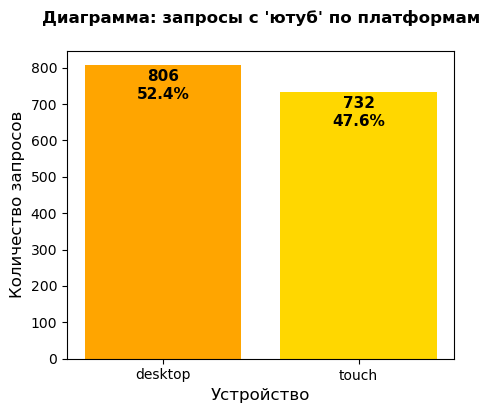

In [19]:
# Выводим таблицу "запросы с 'ютуб' по платформам"
display(df_device.style.set_caption("<span style='font-size: 16px; font-weight: bold; white-space: nowrap;'>Таблица: запросы с 'ютуб' по платформам</span>"))
print(f"\nВсего: {result.sum()} запросов")

# Строим диаграмму "запросы с 'ютуб' по платформам"
fig, ax = plt.subplots(figsize=(5, 4))

bars = ax.bar(df_device['Устройство'], df_device['Количество'], color=['#FFA500', '#FFD700'])

ax.set_title("Диаграмма: запросы с 'ютуб' по платформам", fontsize=12, fontweight='bold', pad=20)
ax.set_xlabel("Устройство",fontsize=12)
ax.set_ylabel("Количество запросов", fontsize=12)

total = df_device['Количество'].sum()
for i, (bar, count) in enumerate(zip(bars, df_device['Количество'])):
    percent = (count / total) * 100
    ax.text(bar.get_x() + bar.get_width()/2, 
            bar.get_height() - 100, 
            f'{count}\n{percent:.1f}%', 
            ha='center', 
            va='bottom',
            fontsize=11, 
            fontweight='bold'
           )

plt.show()

В отличие от общего трафика (где Touch доминирует с отрывом 2-2.5 раза), запросы с "ютуб" демонстрируют приоритет desktop.  
Desktop удобнее для долгого просмотра: большой экран, нет разрядки батареи, комфортнее для фона во время работы.  
YouTube изначально развивался как desktop-платформа. Часть аудитории сохранила привычку смотреть с компьютера

### **3. Выведите топ10 самых частотных запросов в каждой платформе (desktop, touch). Какие отличия вы видите?**

Выделим топ-10 для каждой платформы

In [20]:
top_desktop = df[df['Device'] == 'desktop']['Query'].value_counts().head(10)
top_touch = df[df['Device'] == 'touch']['Query'].value_counts().head(10)

Сравним количество запросов между платформами

In [21]:
print(f"Desktop запросов в топ-10: {top_desktop.sum()}")
print(f"Touch запросов в топ-10: {top_touch.sum()}")
print(f"Touch активнее на: {((top_touch.sum() / top_desktop.sum()) - 1) * 100:.1f}%")

Desktop запросов в топ-10: 14301
Touch запросов в топ-10: 36547
Touch активнее на: 155.6%


У Touch в 2 раза больше запросов в Топ-10 чем у Desktop

Выведем таблицы Топ-10

In [22]:
html_str = """
<div style="display:flex;">
  <div style="width:35%;"><h4>Топ-10 на Desktop</h4>{}</div>
  <div style="width:35%;"><h4>Топ-10 на Touch</h4>{}</div>
</div>
""".format(
    pd.DataFrame({'Количество': top_desktop}).to_html(),
    pd.DataFrame({'Количество': top_touch}).to_html()
)

display(HTML(html_str))

,Количество
Query,
календарь 2021,2802
таблица менделеева,2656
картинки,1720
английский алфавит,1352
обои на рабочий стол,1141
одноклассники (социальная сеть),1114
алфавит,923
таблица квадратов,883
таблица умножения,872


Сделаем диаграммы по таблицам выше

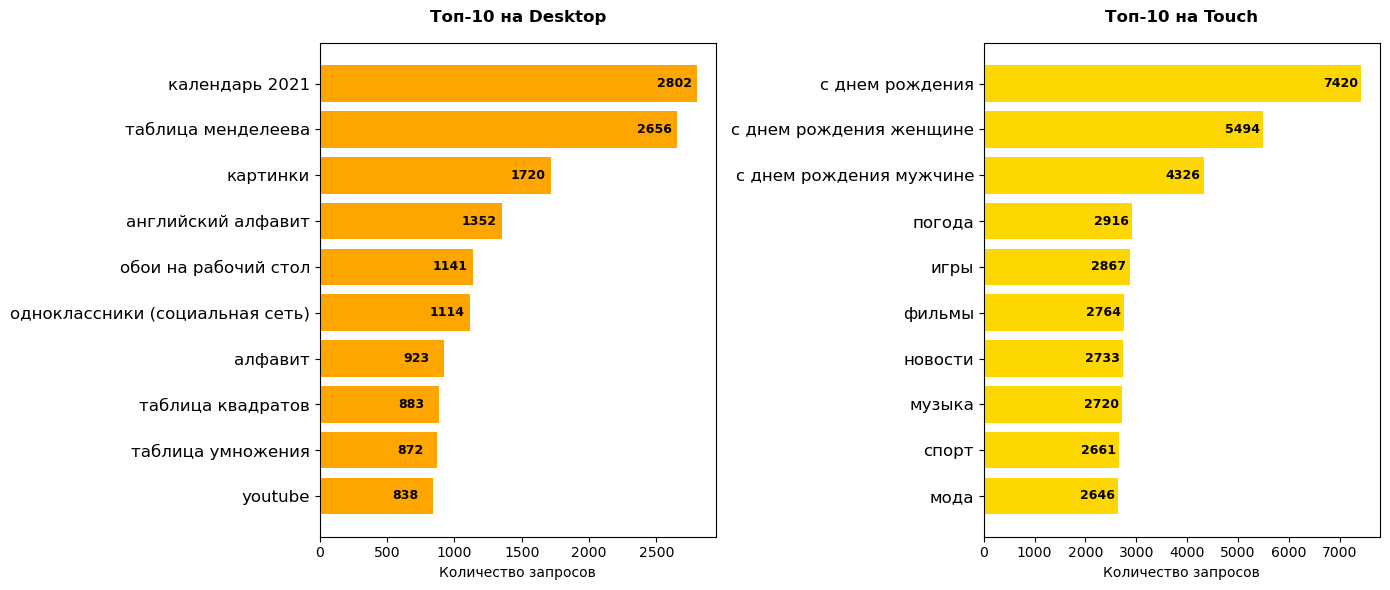

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Desktop
bars1 = ax1.barh(range(len(top_desktop)), top_desktop.values, color='#FFA500')
ax1.set_yticks(range(len(top_desktop)))
ax1.set_yticklabels(top_desktop.index, fontsize=12)
ax1.set_xlabel('Количество запросов', fontsize=10)
ax1.set_title('Топ-10 на Desktop', fontsize=12, fontweight='bold', pad=15)
ax1.invert_yaxis()

for i, (bar, count) in enumerate(zip(bars1, top_desktop.values)):
    ax1.text(count - 300, bar.get_y() + bar.get_height()/2, str(count), va='center', fontsize=9, fontweight='bold')

# Touch
bars2 = ax2.barh(range(len(top_touch)), top_touch.values, color='#FFD700')
ax2.set_yticks(range(len(top_touch)))
ax2.set_yticklabels(top_touch.index, fontsize=12)
ax2.set_xlabel('Количество запросов', fontsize=10)
ax2.set_title('Топ-10 на Touch', fontsize=12, fontweight='bold', pad=15)
ax2.invert_yaxis()

for i, (bar, count) in enumerate(zip(bars2, top_touch.values)):
    ax2.text(count - 750, bar.get_y() + bar.get_height()/2, str(count), va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

У Desktop в топе преимущественно учебные/рабочие запросы.  
У Touch развлекательного характера, досуг.  

40% топ-10 на Touch составляют вариации одного запроса - "С днем рождения"  

Сумма топ-10:  
- Desktop 14 200  
- Touch 33 000  
Топ отражает картину всего датасета - Touch генерирует в 2-2.5 раза больше запросов

### **4. Посмотрите, чем отличается трафик запросов в течении дня. Как можно объяснить отличие?**

Поскольку у нас данные за несколько недель, мы суммируем все запросы по часам, чтобы увидеть **типичный суточный паттерн**  
Но в данных могут быть аномально активные дни - выбросы. Например, праздничные дни.  
Посмотрим активность по дням.

In [24]:
# Извлекаем дату без времени и считаем запросы по дням
df['Date_only'] = pd.to_datetime(df['Date'], unit='s').dt.date
daily_traffic = df.groupby('Date_only').size()

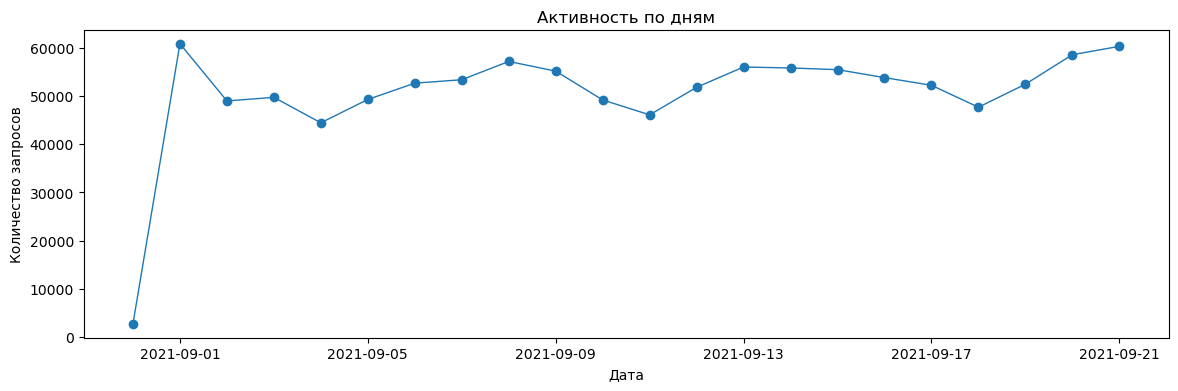

Среднее в день: 50,631
Медиана: 52,555
Стд. отклонение: 11,543
Мин: 2,771
Макс: 60,847


In [25]:
plt.figure(figsize=(14, 4))
plt.plot(daily_traffic.index, daily_traffic.values, marker='o', linewidth=1)
plt.title('Активность по дням')
plt.xlabel('Дата')
plt.ylabel('Количество запросов')
plt.show()

print(f"Среднее в день: {daily_traffic.mean():,.0f}")
print(f"Медиана: {daily_traffic.median():,.0f}")
print(f"Стд. отклонение: {daily_traffic.std():,.0f}")
print(f"Мин: {daily_traffic.min():,.0f}")
print(f"Макс: {daily_traffic.max():,.0f}")

Аномалии на графике выявлены 2021-08-31, 2021-09-01, 2021-09-21  
- Первое сентября - это праздник, но выборс умеренный. Скорее всего, большинство запросов, содержащих "1 сентября", пришлись на этот день. Его можно было бы оставить для изучения **общего поведения**, однако для чистоты **типичного суточного паттерна** исключим его.
- Дни 2021-08-31 и 2021-09-21 технически являются неполными (данные собирались 3 и 21 час соответственно). Хотя вместе они покрывают все 24 часа, принято решение исключить их из анализа по двум причинам:  
31 августа — предпраздничный день (накануне Дня знаний), когда поведение пользователей может отличаться от типичного  
21 сентября — неполный день, который не может быть проанализирован отдельно  

**Итоговый период анализа:** 2–20 сентября 2021 (19 полных дней)

Исключаем неполные и предпраздничные дни

In [26]:
df_clean = df[
    (df['Date_only'] >= pd.Timestamp('2021-09-02').date()) & 
    (df['Date_only'] <= pd.Timestamp('2021-09-20').date())
].copy()

Группируем по часам

In [27]:
df_clean['Hour'] = pd.to_datetime(df_clean['Date'], unit='s').dt.hour
traffic_by_hour = df_clean.groupby(['Device', 'Hour']).size().unstack(fill_value=0)

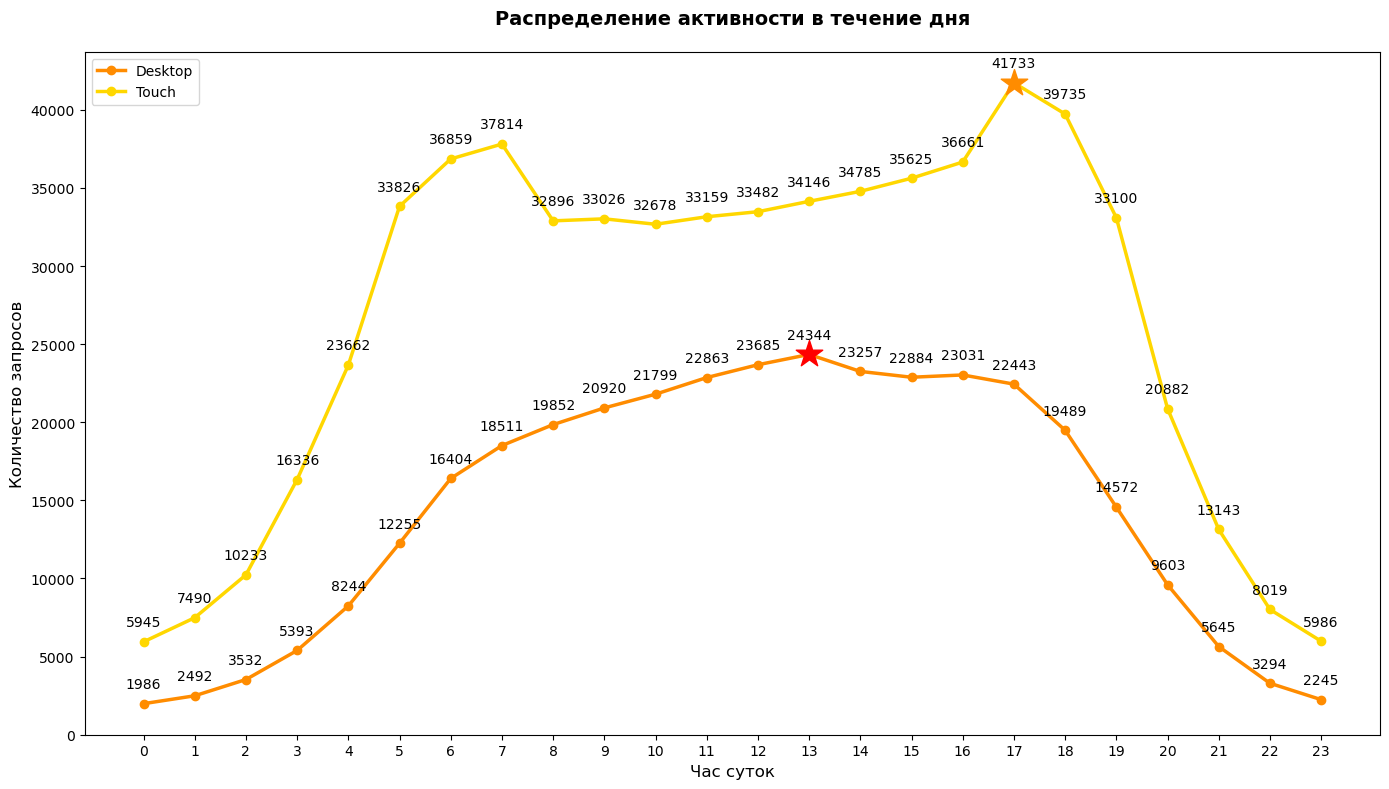

Ключевые показатели

Desktop:
- Пик: 13:00 (24344 запросов)
- Средний в час: 14531
- Всего: 348743

Touch:
- Пик: 17:00 (41733 запросов)
- Средний в час: 26718
- Всего: 641221

Соотношение Touch/Desktop: 1.84


In [28]:
fig, ax = plt.subplots(figsize=(14, 8))

# Desktop
ax.plot(traffic_by_hour.loc['desktop'].index, traffic_by_hour.loc['desktop'].values, marker='o', color='#FF8C00', linewidth=2.5, markersize=6, label='Desktop')
# Отмечаем пик
desktop_peak_hour = traffic_by_hour.loc['desktop'].idxmax()
desktop_peak_val = traffic_by_hour.loc['desktop'].max()
ax.scatter(desktop_peak_hour, desktop_peak_val, s=400, c='red', marker='*', zorder=2)

# Подписи
for hour, count in traffic_by_hour.loc['desktop'].items():
    ax.text(hour, count + 1000, f'{int(count)}', fontsize=10, ha='center')


# Touch
ax.plot(traffic_by_hour.loc['touch'].index, traffic_by_hour.loc['touch'].values, marker='o', color='#FFD700', linewidth=2.5, markersize=6, label='Touch')
# Отмечаем пик
touch_peak_hour = traffic_by_hour.loc['touch'].idxmax()
touch_peak_val = traffic_by_hour.loc['touch'].max()
ax.scatter(touch_peak_hour, touch_peak_val, s=400, c='darkorange', marker='*', zorder=2)

# Подписи
for hour, count in traffic_by_hour.loc['touch'].items():
    ax.text(hour, count + 1000, f'{int(count)}', fontsize=10, ha='center')


ax.set_title('Распределение активности в течение дня', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Час суток', fontsize=12)
ax.set_ylabel('Количество запросов', fontsize=12)
ax.legend(loc='upper left', fontsize=10)
ax.set_xticks(range(0, 24, 1))

plt.tight_layout()
plt.show()


# Выведем ключевые показатели вместе с диаграммой
print("Ключевые показатели")
print(f"\nDesktop:")
print(f"- Пик: {desktop_peak_hour}:00 ({desktop_peak_val} запросов)")
print(f"- Средний в час: {traffic_by_hour.loc['desktop'].mean():.0f}")
print(f"- Всего: {traffic_by_hour.loc['desktop'].sum()}")

print(f"\nTouch:")
print(f"- Пик: {touch_peak_hour}:00 ({touch_peak_val} запросов)")
print(f"- Средний в час: {traffic_by_hour.loc['touch'].mean():.0f}")
print(f"- Всего: {traffic_by_hour.loc['touch'].sum()}")

print(f"\nСоотношение Touch/Desktop: {traffic_by_hour.loc['touch'].sum() / traffic_by_hour.loc['desktop'].sum():.2f}")

Touch генерируют в 2-2.5 раза больше трафика, чем Desktop  

По 2-м графикам можно выделить 4 фазы активности:  
1)  Утренняя (4:00 – 8:00)  
       - Резкий скачок Touch в 5-6 утра. Люди проверяют телефон после пробуждения.  
       - Desktop включается позже, когда люди приходят на работу/учёбу.  
2)  Дневная (8:00 - 16:00)  
       - Desktop: стабильный рост до 13:00, затем плавное снижение  
       - Touch: высокая активность с небольшим провалом в 8:00 (начало рабочего дня)  
       - в рабочее время Desktop используется наравне с Touch, но не доминирует
3)  Вечерняя (16:00 - 22:00)
       - 17:00 - абсолютный максимум для Touch (конец рабочего дня)
       - После 18:00 - резкое падение обеих платформ
       - К 23:00 активность уходит к ночным значениям
4)  Ночная (22:00 - 4:00)
       - Минимальная, но не нулевая активность
       - Touch стабильно выше Desktop

Desktop показывает классическое колоколообразное распределение с единственным пиком в 13:00. Это указывает на то, что компьютеры используются преимущественно в рабочее время, с максимумом во время обеденного перерыва.  
Touch демонстрирует двувершинное (бимодальное) распределение с пиками в 7:00 и 17:00. Утренний пик соответствует времени перед началом рабочего дня, вечерний - окончанию работы и дороге домой.

**Как можно объяснить отличие?**  

Отличие объясняется образом жизни.  
Графики отражают ритм жизни современного человека.   
Desktop - рабочий инструмент, используется ситуативно в офисе/дома за столом.  
Touch - сопровождает людей 24/7: утром, в транспорте, в перерывах, вечером.

### **5. Выделите тематики запросов, контрастные для мобильных и компьютеров - темы, доля которых отличаются на разных платформах**

Мощности машины, на которой будут проводитьтся расчеты, ограничены, поэтому для скорости работы возьмем топ-5000 частых запросов для матрицы TF-IDF.  
По этой же причине для кластеризации выбран способ: TF-IDF + KMeans.  
TF-IDF проанализирует запросы и выделит значимые слова  
KMeans распределит запросы по кластерам

**TF-IDF**

In [29]:
# Копируем из датасета 5000 частых запросов
top_queries = df['Query'].value_counts().head(5000).index
df_sample = df[df['Query'].isin(top_queries)].copy()

In [30]:
# Превращаем текст запросов в числа
vectorizer = TfidfVectorizer(max_features=1000, ngram_range=(1, 2),min_df=5)

In [31]:
# Создаём матрицу TF-IDF
X = vectorizer.fit_transform(df_sample['Query'])

**KMeans**

Группируем запросы в 20 тематических кластеров

In [32]:
kmeans = KMeans(n_clusters=20, random_state=42, n_init=10)
df_sample['Cluster'] = kmeans.fit_predict(X)

Смотрим, какие примеры слов в каждом кластере

In [33]:
for cluster_id in range(20):
    print(f"\nКластер {cluster_id}: {df_sample[df_sample['Cluster'] == cluster_id]['Query'].head(5).tolist()}")
    print(f"Всего запросов: {(df_sample['Cluster'] == cluster_id).sum()}")


Кластер 0: ['психология', 'полина гагарина', 'кадр из фильма', 'айфон 13', 'картинки']
Всего запросов: 561019

Кластер 1: ['обои на айфон', 'обои на рабочий стол красивые большие на весь экран бесплатно', 'фото на рабочий стол', 'обои на рабочий стол красивые большие на весь экран бесплатно', 'обои на рабочий стол 4к']
Всего запросов: 4799

Кластер 2: ['с 1 сентября', '1 сентября', '1 сентября день знаний', '3 сентября мем', '3 сентября шуфутинский мем']
Всего запросов: 13820

Кластер 3: ['доброе утро картинки', 'доброе утро', 'доброе утро со смыслом', 'доброе утро картинки прикольные', 'доброе утречко']
Всего запросов: 9430

Кластер 4: ['поздравления с днем рождения женщине', 'поздравления с днем рождения женщине', 'поздравления с днем рождения женщине', 'поздравления с днем рождения женщине', 'красивые поздравления с днем рождения']
Всего запросов: 5253

Кластер 5: ['технологии', 'технологии', 'технологии', 'технологии', 'технологии']
Всего запросов: 3405

Кластер 6: ['схема метро м

**В Кластер 0 попали все запросы, которые не подошли другим кластерам. Он считается мусорным, исключим его из анализа.**

In [34]:
df_sample = df_sample[df_sample['Cluster'] != 0]

Считаем долю каждого кластера на Desktop и Touch

In [35]:
cluster_distribution = pd.crosstab(df_sample['Cluster'], df_sample['Device'], normalize='index' ) * 100
cluster_distribution['Theme'] = cluster_distribution.index.map(lambda x: df_sample[df_sample['Cluster'] == x]['Query'].value_counts().head(1).index[0])

display(cluster_distribution.round(1))

Device,desktop,touch,Theme
Cluster,,,
1,88.3,11.7,обои на рабочий стол
2,16.2,83.8,с 1 сентября
3,6.9,93.1,доброе утро
4,11.0,89.0,поздравления с днем рождения женщине
5,14.8,85.2,технологии
6,21.7,78.3,карта метро москвы
7,11.6,88.4,с днем рождения женщине
8,14.2,85.8,путешествия
9,14.5,85.5,новости


В талице выделены 19 кластеров и доли их распределения по устройствам

Теперь найдем тематики запросов, контрастные для мобильных и компьютеров

In [36]:
# Считаем Touch% - Desktop%
cluster_distribution['Diff'] = cluster_distribution['touch'] - cluster_distribution['desktop']

# Сортируем по модулю разницы
cluster_distribution['Abs_Diff'] = abs(cluster_distribution['Diff'])
cluster_distribution = cluster_distribution.sort_values('Abs_Diff', ascending=False)

In [37]:
for cluster_id in cluster_distribution.index:
    row = cluster_distribution.loc[cluster_id]
    
    print(f"\nКластер {cluster_id}: {df_sample[df_sample['Cluster'] == cluster_id]['Query'].value_counts().head(1).index[0]}")
    print(f"Desktop: {row['desktop']:.1f}%  -  Touch: {row['touch']:.1f}%  =  Разница: {row['Diff']:+.1f}%")


Кластер 10: одноклассники (социальная сеть)
Desktop: 98.3%  -  Touch: 1.7%  =  Разница: -96.6%

Кластер 19: с добрым утром
Desktop: 5.2%  -  Touch: 94.8%  =  Разница: +89.6%

Кластер 3: доброе утро
Desktop: 6.9%  -  Touch: 93.1%  =  Разница: +86.2%

Кластер 16: с днем рождения
Desktop: 8.0%  -  Touch: 92.0%  =  Разница: +84.0%

Кластер 13: спокойной ночи
Desktop: 8.0%  -  Touch: 92.0%  =  Разница: +84.0%

Кластер 11: с днем рождения мужчине
Desktop: 9.7%  -  Touch: 90.3%  =  Разница: +80.6%

Кластер 4: поздравления с днем рождения женщине
Desktop: 11.0%  -  Touch: 89.0%  =  Разница: +78.0%

Кластер 7: с днем рождения женщине
Desktop: 11.6%  -  Touch: 88.4%  =  Разница: +76.9%

Кластер 1: обои на рабочий стол
Desktop: 88.3%  -  Touch: 11.7%  =  Разница: -76.5%

Кластер 17: кулинария
Desktop: 13.4%  -  Touch: 86.6%  =  Разница: +73.3%

Кластер 8: путешествия
Desktop: 14.2%  -  Touch: 85.8%  =  Разница: +71.5%

Кластер 12: погода
Desktop: 14.5%  -  Touch: 85.5%  =  Разница: +71.1%

Класт

График контрастности тем (разницы в долях)

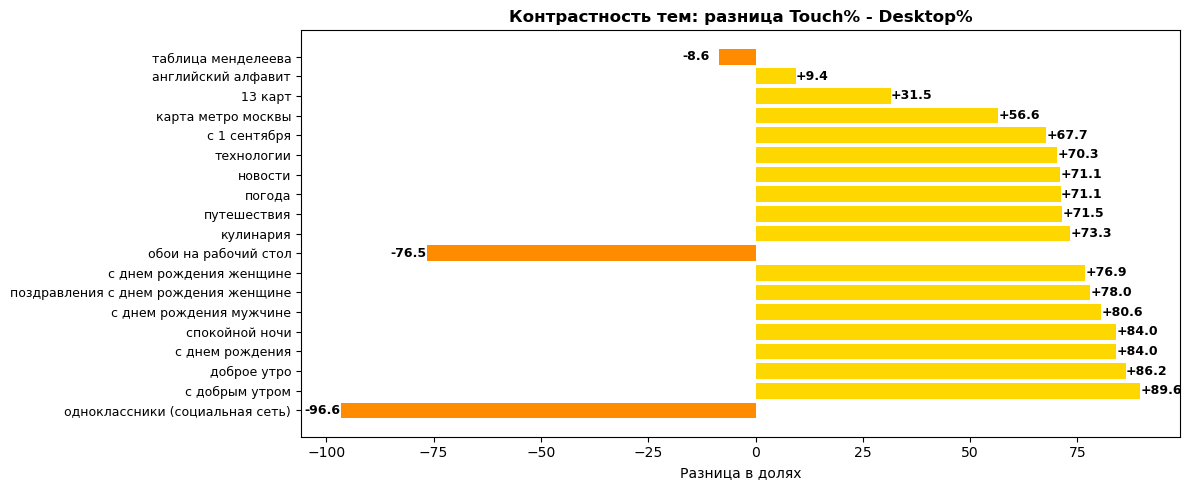

In [38]:
fig, ax = plt.subplots( figsize=(12, 5))

colors = ['#FFD700' if x > 0 else '#FF8C00' for x in cluster_distribution['Diff']]

bars = ax.barh(range(len(cluster_distribution)), cluster_distribution['Diff'], color=colors)
ax.set_title('Контрастность тем: разница Touch% - Desktop%', fontweight='bold')
ax.set_xlabel('Разница в долях')
ax.set_yticks(range(len(cluster_distribution)))
ax.set_yticklabels(cluster_distribution['Theme'], fontsize=9)

# Подписи на столбцах
for bar, value in zip(bars, cluster_distribution['Diff']):
    ax.text(value + (0.1 if value > 0 else -8.5), bar.get_y() + bar.get_height()/2, f'{value:+.1f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

**Touch (мобильное устройство)**  
- Социальные ритуалы (поздравления, приветствия)
- Быстрая информация (погода, новости)
- Повседневные задачи (кулинария, путешествия)
- Эмоциональный поиск (поздравить, поделиться)

**Desktop (компьютер)**  
- Рабочий контекст (оформление рабочего места)
- Образование (справочники, таблицы)
- Соц.сети со взрослой аудиторией (Одноклассники)
- Целенаправленный поиск (конкретные материалы)

**Самая контрастная тема:** Одноклассники(социальная сеть)  
**Самая Desktop(компьютерная) тема:** Одноклассники(социальная сеть)  
**Самая Touch(мобильная) тема:** С добрым утром  
**Количество Touch-тем:** 16 из 19  
**Количество Desktop-тем:** 3 из 19  

**Темы с минимальной разницей:** таблица менделеева, английский алфавит  

**83% тематик доминируют на мобильных устройствах**

(Для выделения тематик использован алгоритм KMeans. Запросы были векторизованы через TF-IDF. Выбрано 20 кластеров для детализации тем. random_state зафиксирован для воспроизводимости результатов)

<a class="anchor" id="4-bullet"></a>
## Анализ недельной активности (SQL)

#### Сделаем анализ активности по дням недели

Мы будем анализировать реальное поведение пользователей за предоставленный период

Проверяем подключение pysqldf

In [39]:
pysqldf = lambda q: sqldf(q, globals())
print(pysqldf("SELECT COUNT(*) FROM df"))

   COUNT(*)
0   1113882


Выведем дни в порядке убывания количества запросов

In [40]:
query = """
SELECT
    CASE CAST(strftime('%w', Date) AS INTEGER)
        WHEN 0 THEN 'Воскресенье'
        WHEN 1 THEN 'Понедельник'
        WHEN 2 THEN 'Вторник'
        WHEN 3 THEN 'Среда'
        WHEN 4 THEN 'Четверг'
        WHEN 5 THEN 'Пятница'
        WHEN 6 THEN 'Суббота'
    END AS День_недели,
    COUNT(*) AS Всего_запросов,
    COUNT(DISTINCT Query) AS Уникальных_запросов,
    COUNT(CASE WHEN Device = 'desktop' THEN 1 END) AS Запросов_с_компьютеров,
    COUNT(CASE WHEN Device = 'touch' THEN 1 END) AS Запросов_с_мобильных,
    ROUND(COUNT(CASE WHEN Device = 'touch' THEN 1 END) * 100.0 / COUNT(*), 2) AS Доля_запросов_с_мобильных,
    ROUND(COUNT(CASE WHEN Device = 'desktop' THEN 1 END) * 100.0 / COUNT(*), 2) AS Доля_запросов_с_компьютеров
FROM df
GROUP BY CAST(strftime('%w', Date) AS INTEGER)
ORDER BY Всего_запросов DESC
"""

result = pysqldf(query)
display(result)

,День_недели,Всего_запросов,Уникальных_запросов,Запросов_с_компьютеров,Запросов_с_мобильных,Доля_запросов_с_мобильных,Доля_запросов_с_компьютеров
0,Среда,173488,22549,58662,114826,66.19,33.81
1,Вторник,172262,22805,63246,109016,63.28,36.72
2,Понедельник,167262,22751,62137,105125,62.85,37.15
3,Четверг,157961,22681,57977,99984,63.30,36.70
4,Воскресенье,153544,22671,50743,102801,66.95,33.05
5,Пятница,151141,22445,53105,98036,64.86,35.14
6,Суббота,138224,22128,42318,95906,69.38,30.62


**Среда** - пик активности (173488)  
**Вторник** на втором месте (172262)  
Середина недели - самая продуктивная для пользователей

**Суббота** (138224) - абсолютный минимум (−20% от среды)  
В **Воскресенье** активность повышается, люди готовятся к неделе

Самая высокая доля мобильных устройств в **Субботу**. Самая низкая в **Понедельник**

В начале недели доли запросов с компьютеров выше чем в конце недели. У мобильных наоборот.

#### Посмотрим распределение запросов по дням недели и в течении дня

In [41]:
query = """
SELECT 
    CASE CAST(strftime('%w', Date) AS INTEGER)
        WHEN 0 THEN 'Воскресенье'
        WHEN 1 THEN 'Понедельник'
        WHEN 2 THEN 'Вторник'
        WHEN 3 THEN 'Среда'
        WHEN 4 THEN 'Четверг'
        WHEN 5 THEN 'Пятница'
        WHEN 6 THEN 'Суббота'
    END AS День_недели,
    CAST(strftime('%H', Date) AS INTEGER) AS Час,
    COUNT(*) AS Всего_запросов
FROM df
GROUP BY День_недели, Час
"""

In [42]:
# Получаем данные
heatmap_data = pysqldf(query)

Создаем сводную таблицу, где слева расположены дни недели, сверху часы

In [43]:
pivot_table = heatmap_data.pivot(index='День_недели', columns='Час', values='Всего_запросов')

# Порядок дней
day_order = ['Понедельник', 'Вторник', 'Среда', 'Четверг', 'Пятница', 'Суббота', 'Воскресенье']
pivot_table = pivot_table.reindex(day_order)

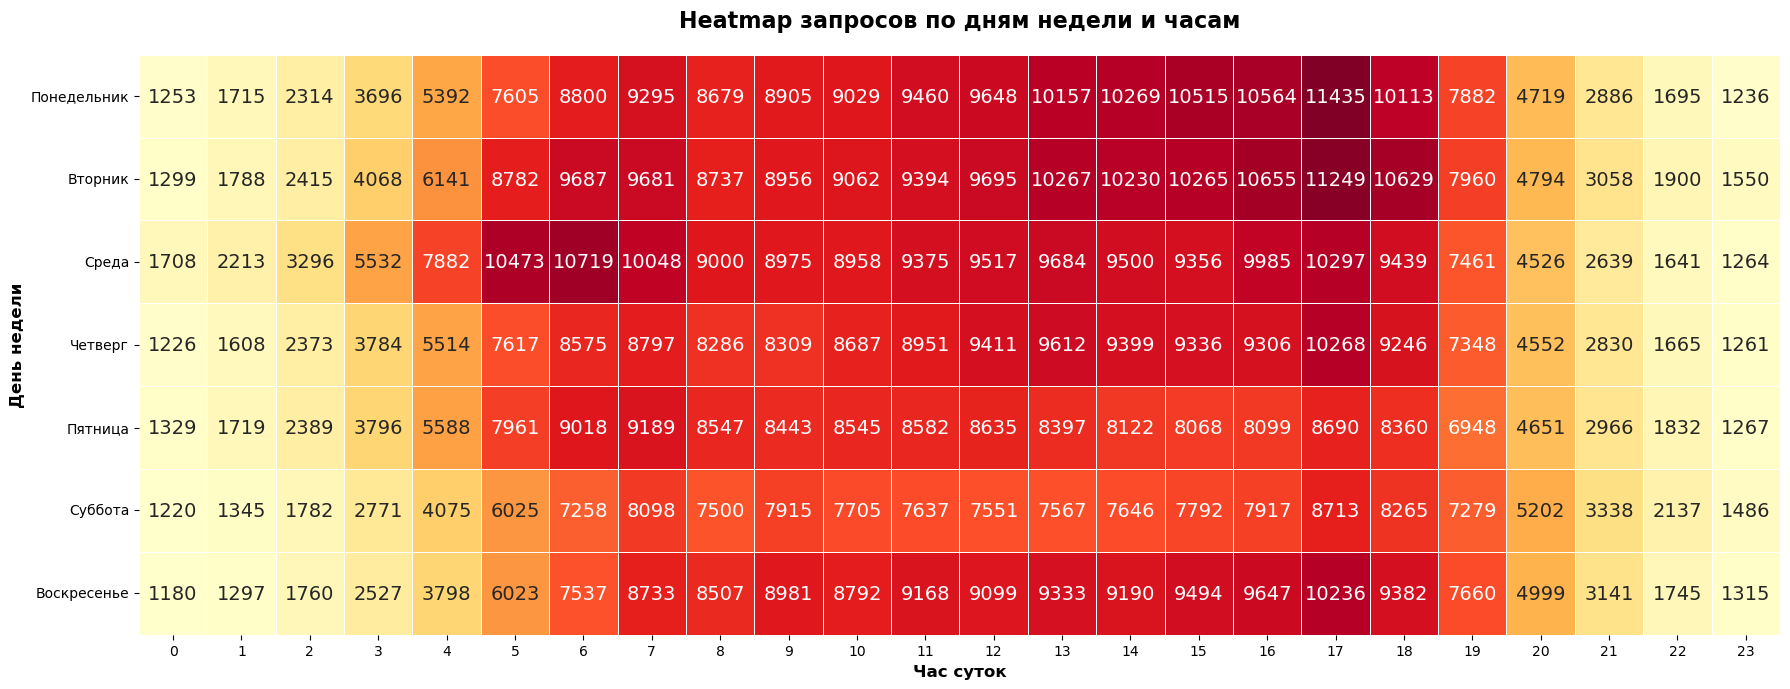

In [44]:
fig, ax = plt.subplots(figsize=(18, 7))

sns.heatmap(
    pivot_table,
    annot=True,  # Показывать числа
    fmt='',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar=False,
    linecolor='white',
    annot_kws={'size': 14},
    ax=ax
)

plt.title('Heatmap запросов по дням недели и часам', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Час суток', fontsize=12, fontweight='bold')
plt.ylabel('День недели', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

Картина сильно схожа с графиком часов в течении дня.  
Ночью минимальная активность, начиная с 5 утра и до 19 она держится на высоком плато, далее идет на спад.  
Можно выделитьо самые активные часы недели: 17:00 Понедельник/Вторник и 6:00 Среда  
Самый низкий: 0:00 Суббота/Воскресенье  

Можно заметить, что Суббота проходит высветленной полосой - самая низкая акивность на неделе в течении дня.

#### Динамика запросов на разных типах устройств

Найдем отношение количества запросов текущей даты ко вчерашней отдельно для каждого типа устройств.

In [45]:
query = """
WITH daily_changes AS (
    SELECT 
        date(Date) AS Дата,
        Device AS Тип_устройства,
        ROUND(
            (COUNT(*) - LAG(COUNT(*), 1) OVER (
                PARTITION BY Device 
                ORDER BY date(Date)
            )) * 100.0 / COUNT(*), 
            1
        ) AS Изменение_процент
    FROM df
    GROUP BY Дата, Тип_устройства
)
SELECT 
    Дата,
    MAX(CASE WHEN Тип_устройства = 'desktop' THEN Изменение_процент END) AS Изменение_для_компьютеров,
    MAX(CASE WHEN Тип_устройства = 'touch' THEN Изменение_процент END) AS Изменение_для_мобильных

FROM daily_changes
GROUP BY Дата
ORDER BY Дата
LIMIT 10
"""

result = pysqldf(query)
display(result)

,Дата,Изменение_для_компьютеров,Изменение_для_мобильных
0,2021-08-31,NaN,NaN
1,2021-09-01,96.1,95.2
2,2021-09-02,1.5,-38.1
3,2021-09-03,-5.4,4.9
4,2021-09-04,-21.6,-7.7
5,2021-09-05,16.0,6.9
6,2021-09-06,16.8,0.4
7,2021-09-07,2.5,0.7
8,2021-09-08,6.1,7.0
9,2021-09-09,-0.6,-5.5


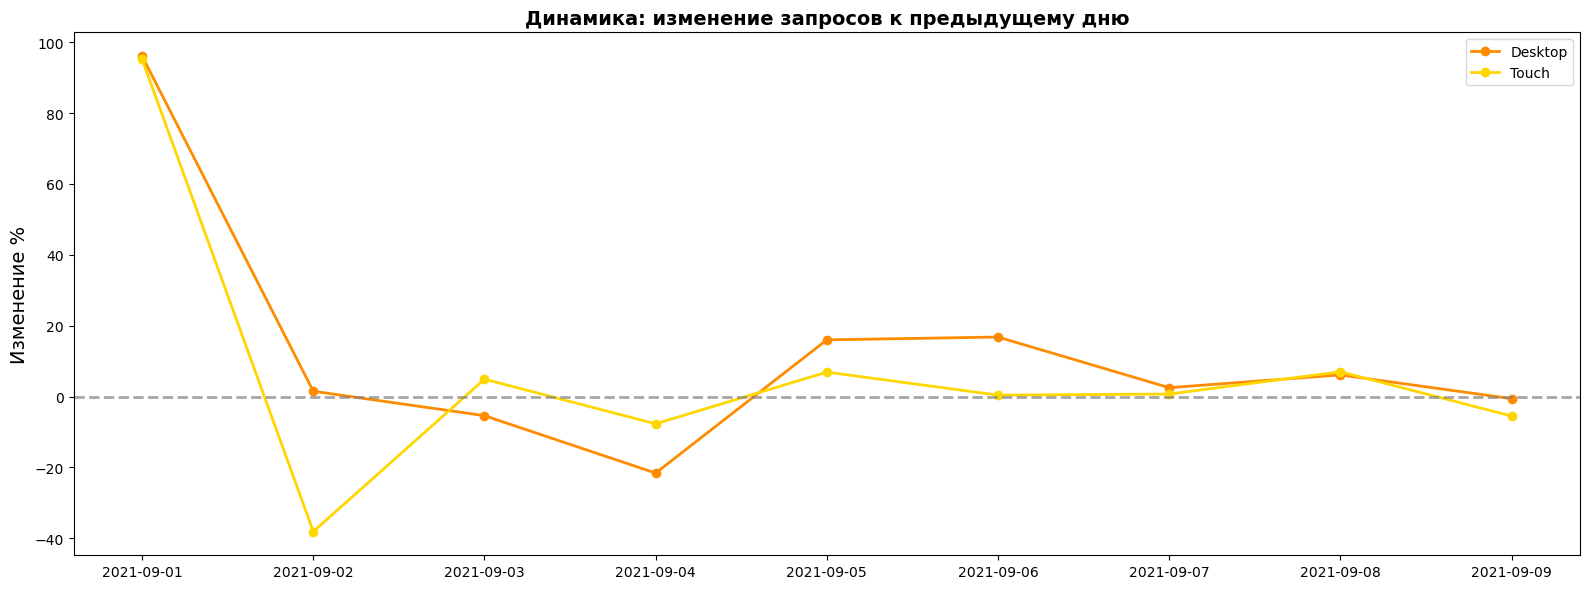

In [46]:
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(result['Дата'], result['Изменение_для_компьютеров'], marker='o', color='#FF8C00', linewidth=2, label='Desktop')
ax.plot(result['Дата'], result['Изменение_для_мобильных'], marker='o', color='#FFD700', linewidth=2, label='Touch')

ax.set_title('Динамика: изменение запросов к предыдущему дню', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Изменение %',fontsize=14)
ax.axhline(y=0, color='gray', linestyle='--', linewidth=2, alpha=0.7)
ax.legend()
plt.tight_layout()
plt.show()

После 1 сентября, резкое падение количества запросов.  
Постепенное востановление и закрепление на плато(нет резких скачков). Мобильные и компьютерные устройства практически сравнялись.  
Значит, на обеих платформах закрепляется стабильное количество запросов изо дня в день.

<a class="anchor" id="5-bullet"></a>
## Дашборд в DataLens

[Дашборд в DataLens](https://datalens.yandex/jiqhmjsffdja3) - интерактивный дашборд по семплу data.tsv

Ссылка: https://datalens.yandex/jiqhmjsffdja3

### Описание

**Назначение:** Мониторинг поведения пользователей, выявление паттернов активности и контентных предпочтений на платформах Desktop и Touch. Проверка гипотезы, что интересы людей, пользующихся поиском по картинкам на мобильных устройствах и на компьютерах заметно отличаются.

**Структура:** 3 вкладки
1) Графики
2) Топ запросов
3) Аналитическая записка

#### Графики  
Количество запросов  
Количество уникальных запросов  
Отношение количества запросов на мобильных устройствах к количеству запросов на компьютерах  
Линейный график - Количество запросов по дням  
Линейный график - Количество запросов по дням недели и типам устройств  
Линейный график - Количество запросов по часам и типам устройств  

#### Топ запросов  
Топ запросов по всем типам устройств  
Топ-10 запросов на мобильных устройствах  
Топ-10 запросов на компьютерах  
Топ запросов содержащих "ютуб"  
Столбчатая диаграмма - Количество запросов содержащих"ютуб" по платформам

#### Аналитическая записка  
Выводы по дашборду, рекомендации и ответ на гипотезу

#### Глобальные селекторы  
Дата - выбор диапазона дат  
Час - выбор часов суточного цикла  

<a class="anchor" id="6-bullet"></a>
## Итоговые выводы и рекомендации

### Итоговый вывод

**Гипотеза:** Интересы людей, пользующихся поиском по картинкам на мобильных устройствах и на компьютерах, заметно отличаются.

Проведённый анализ подтверждает гипотезу о том, что интересы пользователей поиска по картинкам существенно отличаются в зависимости от типа устройства.   

Различия носят выраженный характер: в отдельных тематиках доля запросов одного типа устройств достигает 96%. Например, запросы, связанные с социальной сетью "Одноклассники", практически полностью относятся к компьютерному трафику.

Кластеризация запросов показала высокую контрастность тем:  
14 из 19 кластеров демонстрируют различие более 70% между мобильными и десктопными устройствами.


Также наблюдаются различия в поведенческих паттернах активности:  
- Desktop - активность в рабочие часы (8:00 - 17:00)  
- Touch - пики утром и вечером (5:00-8:00 и 16:00-19:00)  


Это указывает на различный контекст использования устройств:  
- Desktop чаще используется для рабочих и образовательных задач  
- Mobile для быстрой информации, повседневных задач и досуга

83% тематик чаще встречаются на мобильных устройствах, общий объём мобильного трафика составляет 65% всех запросов, что подтверждает доминирование мобильных устройств в поиске по картинкам

### Рекомендации

Для мобильных устройств улучшить выдачу и релевантность результатов для тематик:  
- открытки
- поздравления
- погода
- игры
- музыка
- спорт  

Эти категории связаны с быстрым потреблением контента и повседневными задачами пользователей
___

Для компьютеров Сосредоточиться на тематиках, связанных с:  
- образования  
- работы
- планирование

Такие запросы предполагают более длительное взаимодействие с контентом и чаще выполняются на компьютерах
___

Дополнительно  
Рекомендуется использовать подготовленный [Дашборд](https://datalens.yandex/jiqhmjsffdja3) для мониторинга динамики запросов и отслеживания изменений пользовательских паттернов во времени.